In [1]:
from pathlib import Path

def find_project_root(start: Path, markers=("pyproject.toml", ".git")):
    for p in [start] + list(start.parents):
        if any((p / m).exists() for m in markers):
            return p
    raise RuntimeError("Project root not found")

ROOT = find_project_root(Path.cwd())

print(ROOT)

/home/urdatorn/git/gh/aristophanis-cantica


# Corpus

In [2]:
from aristophanis_cantica.stats import accentual_responsion_metric_corpus

accentual_responsion_stat = accentual_responsion_metric_corpus(ROOT / 'data/compiled')
print(f'Accentual responsion compatibility: {accentual_responsion_stat}')


accentually_responding_syllables_of_lines_polystrophic: 
	Mixed types at ordinal 3 in lines ['376', '381'].

accentually_responding_syllables_of_lines_polystrophic: 
	Mixed types at ordinal 4 in lines ['399', '404', '409'].

accentually_responding_syllables_of_lines_polystrophic: 
	Mixed types at ordinal 8 in lines ['399', '404', '409'].

accentually_responding_syllables_of_lines_polystrophic: 
	Mixed types at ordinal 6 in lines ['399', '405', '410'].

accentually_responding_syllables_of_lines_polystrophic: 
	Mixed types at ordinal 8 in lines ['399', '405', '410'].

accentually_responding_syllables_of_lines_polystrophic: 
	Mixed types at ordinal 12 in lines ['448-449', '454-455'].

accentually_responding_syllables_of_lines_polystrophic: 
	Mixed types at ordinal 19 in lines ['534-535', '590-591'].

accentually_responding_syllables_of_lines_polystrophic:
	All double types at ordinal 11 in lines ['537-539', '593'].

accentually_responding_syllables_of_lines_polystrophic:
	All double type

# Play regression


accentually_responding_syllables_of_lines_polystrophic:
	All double types at ordinal 3 in lines ['211-212', '226'].

accentually_responding_syllables_of_lines_polystrophic:
	All double types at ordinal 6 in lines ['211-212', '226'].

accentually_responding_syllables_of_lines_polystrophic:
	All double types at ordinal 9 in lines ['211-212', '226'].

accentually_responding_syllables_of_lines_polystrophic: 
	Mixed types at ordinal 18 in lines ['215-217', '230-233'].

accentually_responding_syllables_of_lines_polystrophic:
	All double types at ordinal 21 in lines ['215-217', '230-233'].

accentually_responding_syllables_of_lines_polystrophic:
	All double types at ordinal 24 in lines ['215-217', '230-233'].

accentually_responding_syllables_of_lines_polystrophic:
	All double types at ordinal 27 in lines ['215-217', '230-233'].

accentually_responding_syllables_of_lines_polystrophic:
	All double types at ordinal 30 in lines ['215-217', '230-233'].

accentually_responding_syllables_of_lines_

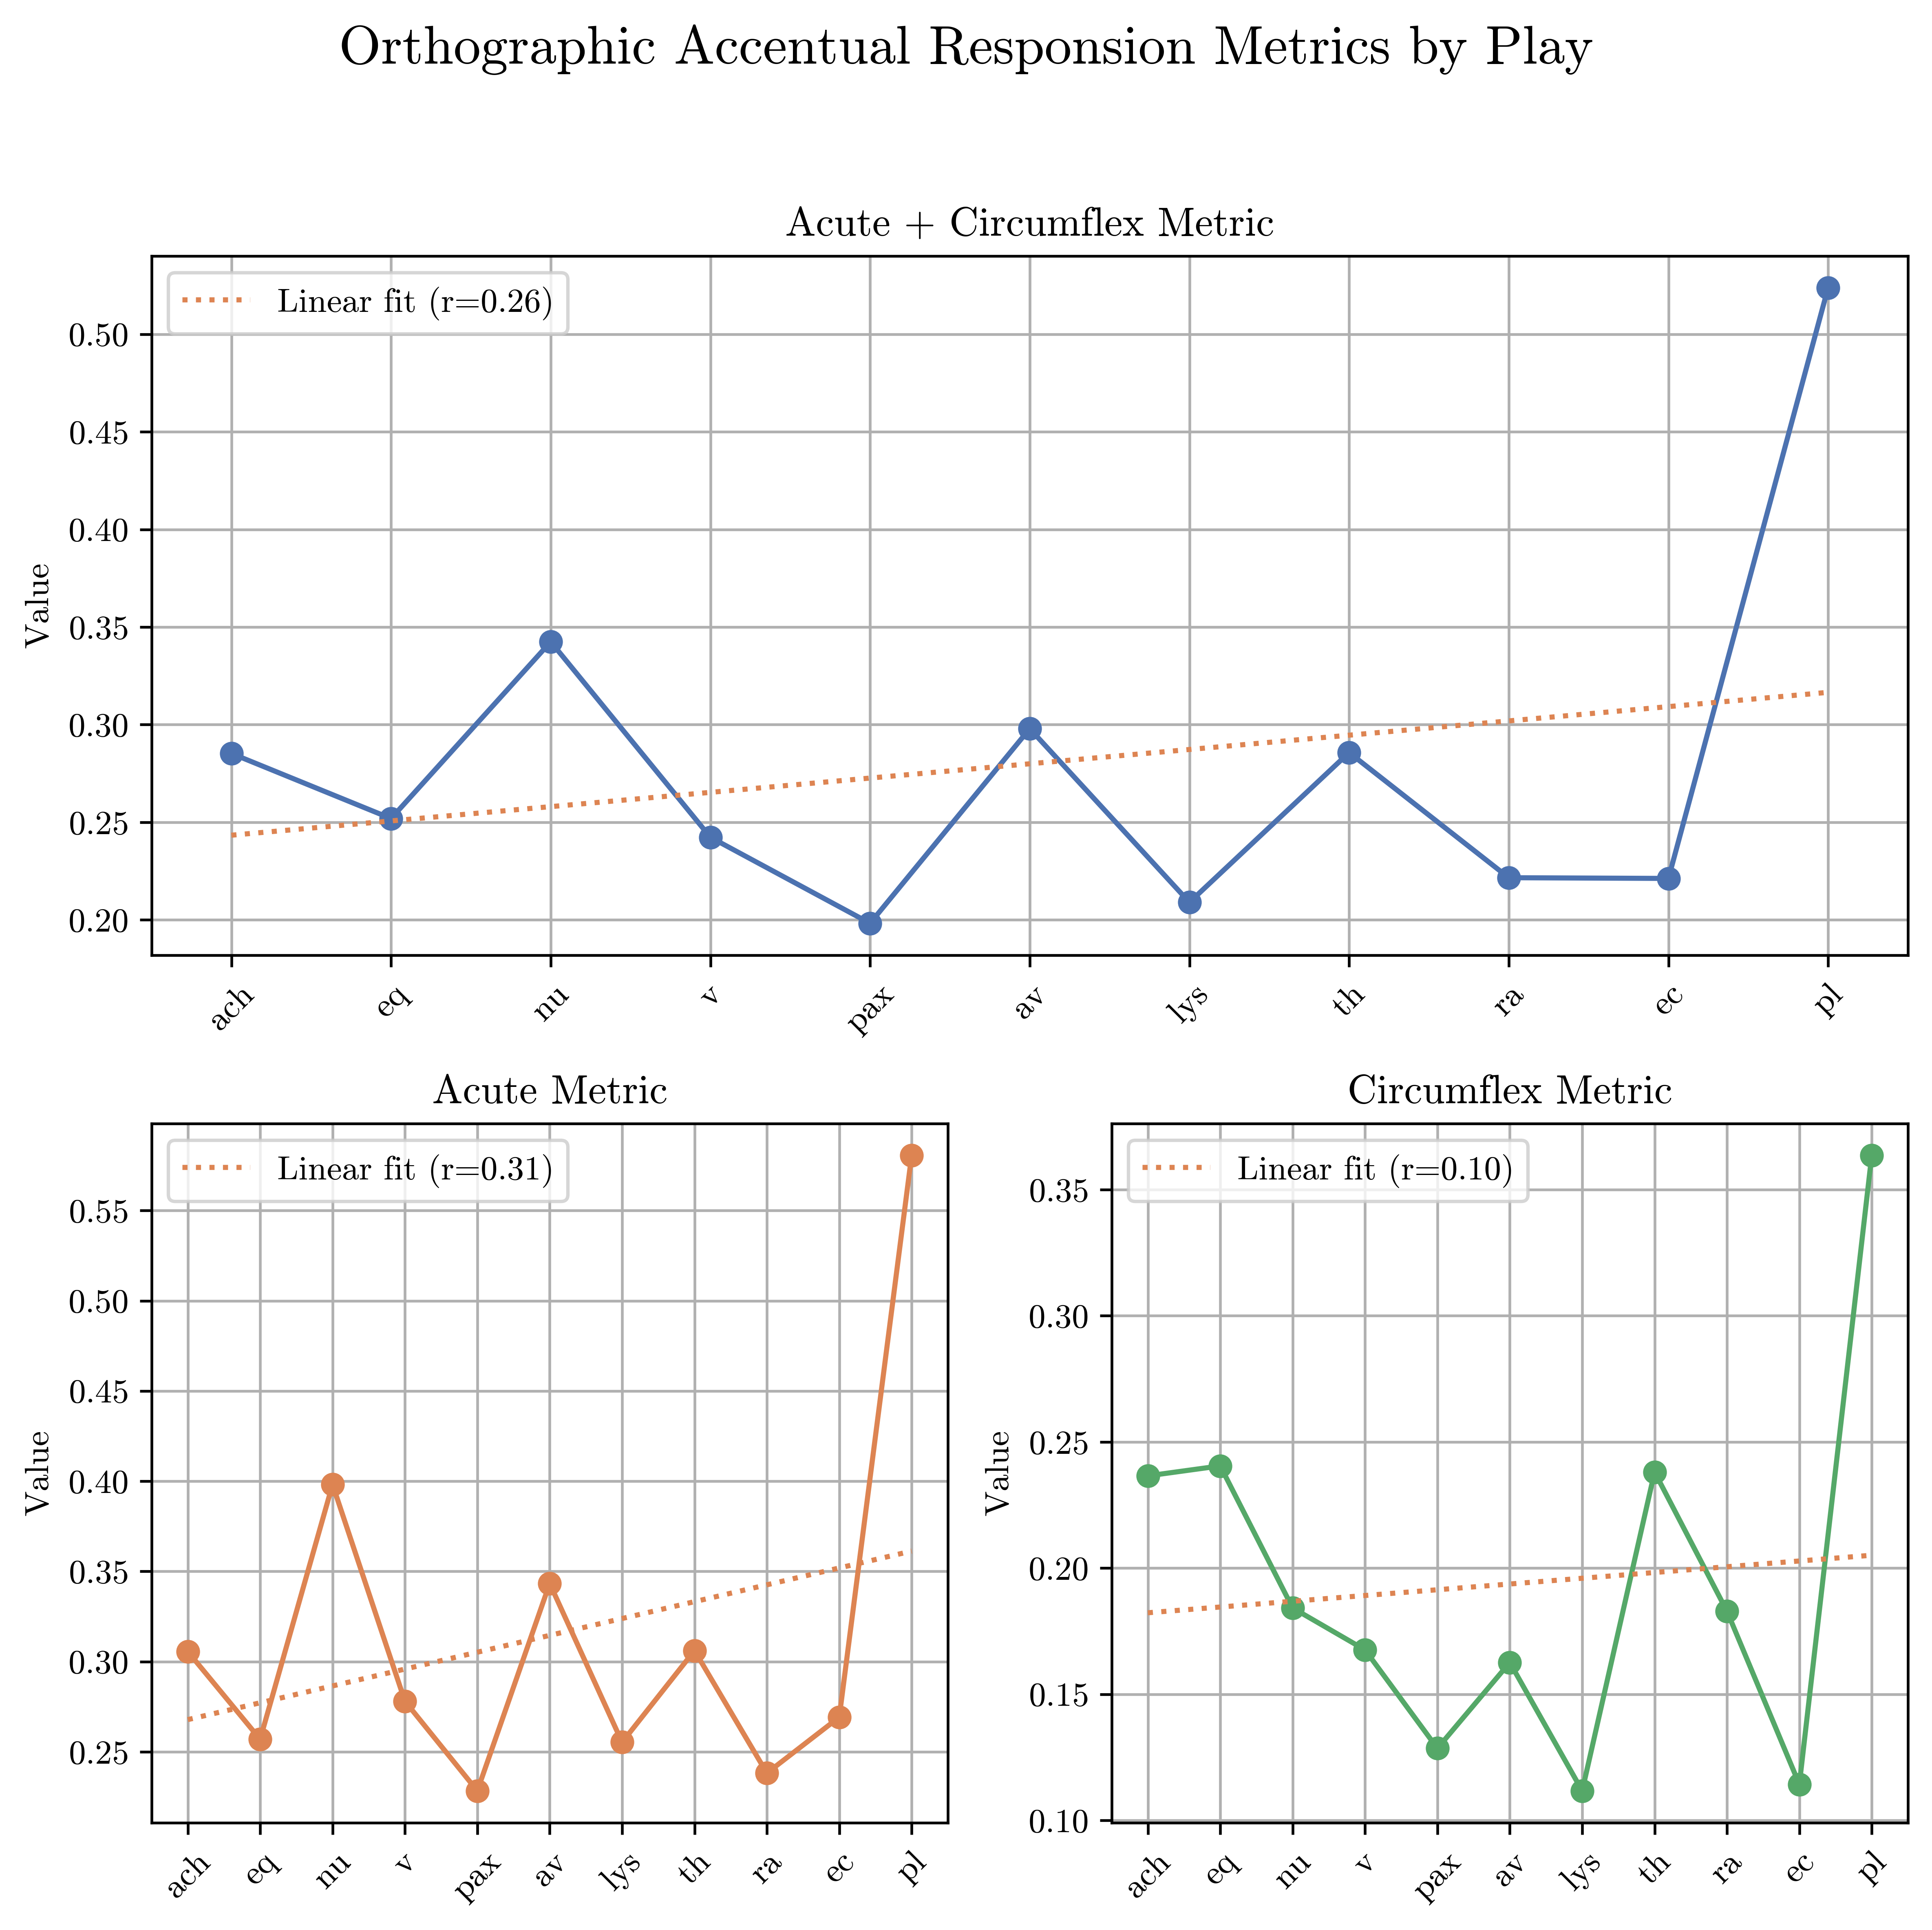


accentually_responding_syllables_of_lines_polystrophic:
	All double types at ordinal 3 in lines ['211-212', '226'].

accentually_responding_syllables_of_lines_polystrophic:
	All double types at ordinal 6 in lines ['211-212', '226'].

accentually_responding_syllables_of_lines_polystrophic:
	All double types at ordinal 9 in lines ['211-212', '226'].

accentually_responding_syllables_of_lines_polystrophic: 
	Mixed types at ordinal 18 in lines ['215-217', '230-233'].

accentually_responding_syllables_of_lines_polystrophic:
	All double types at ordinal 21 in lines ['215-217', '230-233'].

accentually_responding_syllables_of_lines_polystrophic:
	All double types at ordinal 24 in lines ['215-217', '230-233'].

accentually_responding_syllables_of_lines_polystrophic:
	All double types at ordinal 27 in lines ['215-217', '230-233'].

accentually_responding_syllables_of_lines_polystrophic:
	All double types at ordinal 30 in lines ['215-217', '230-233'].

accentually_responding_syllables_of_lines_

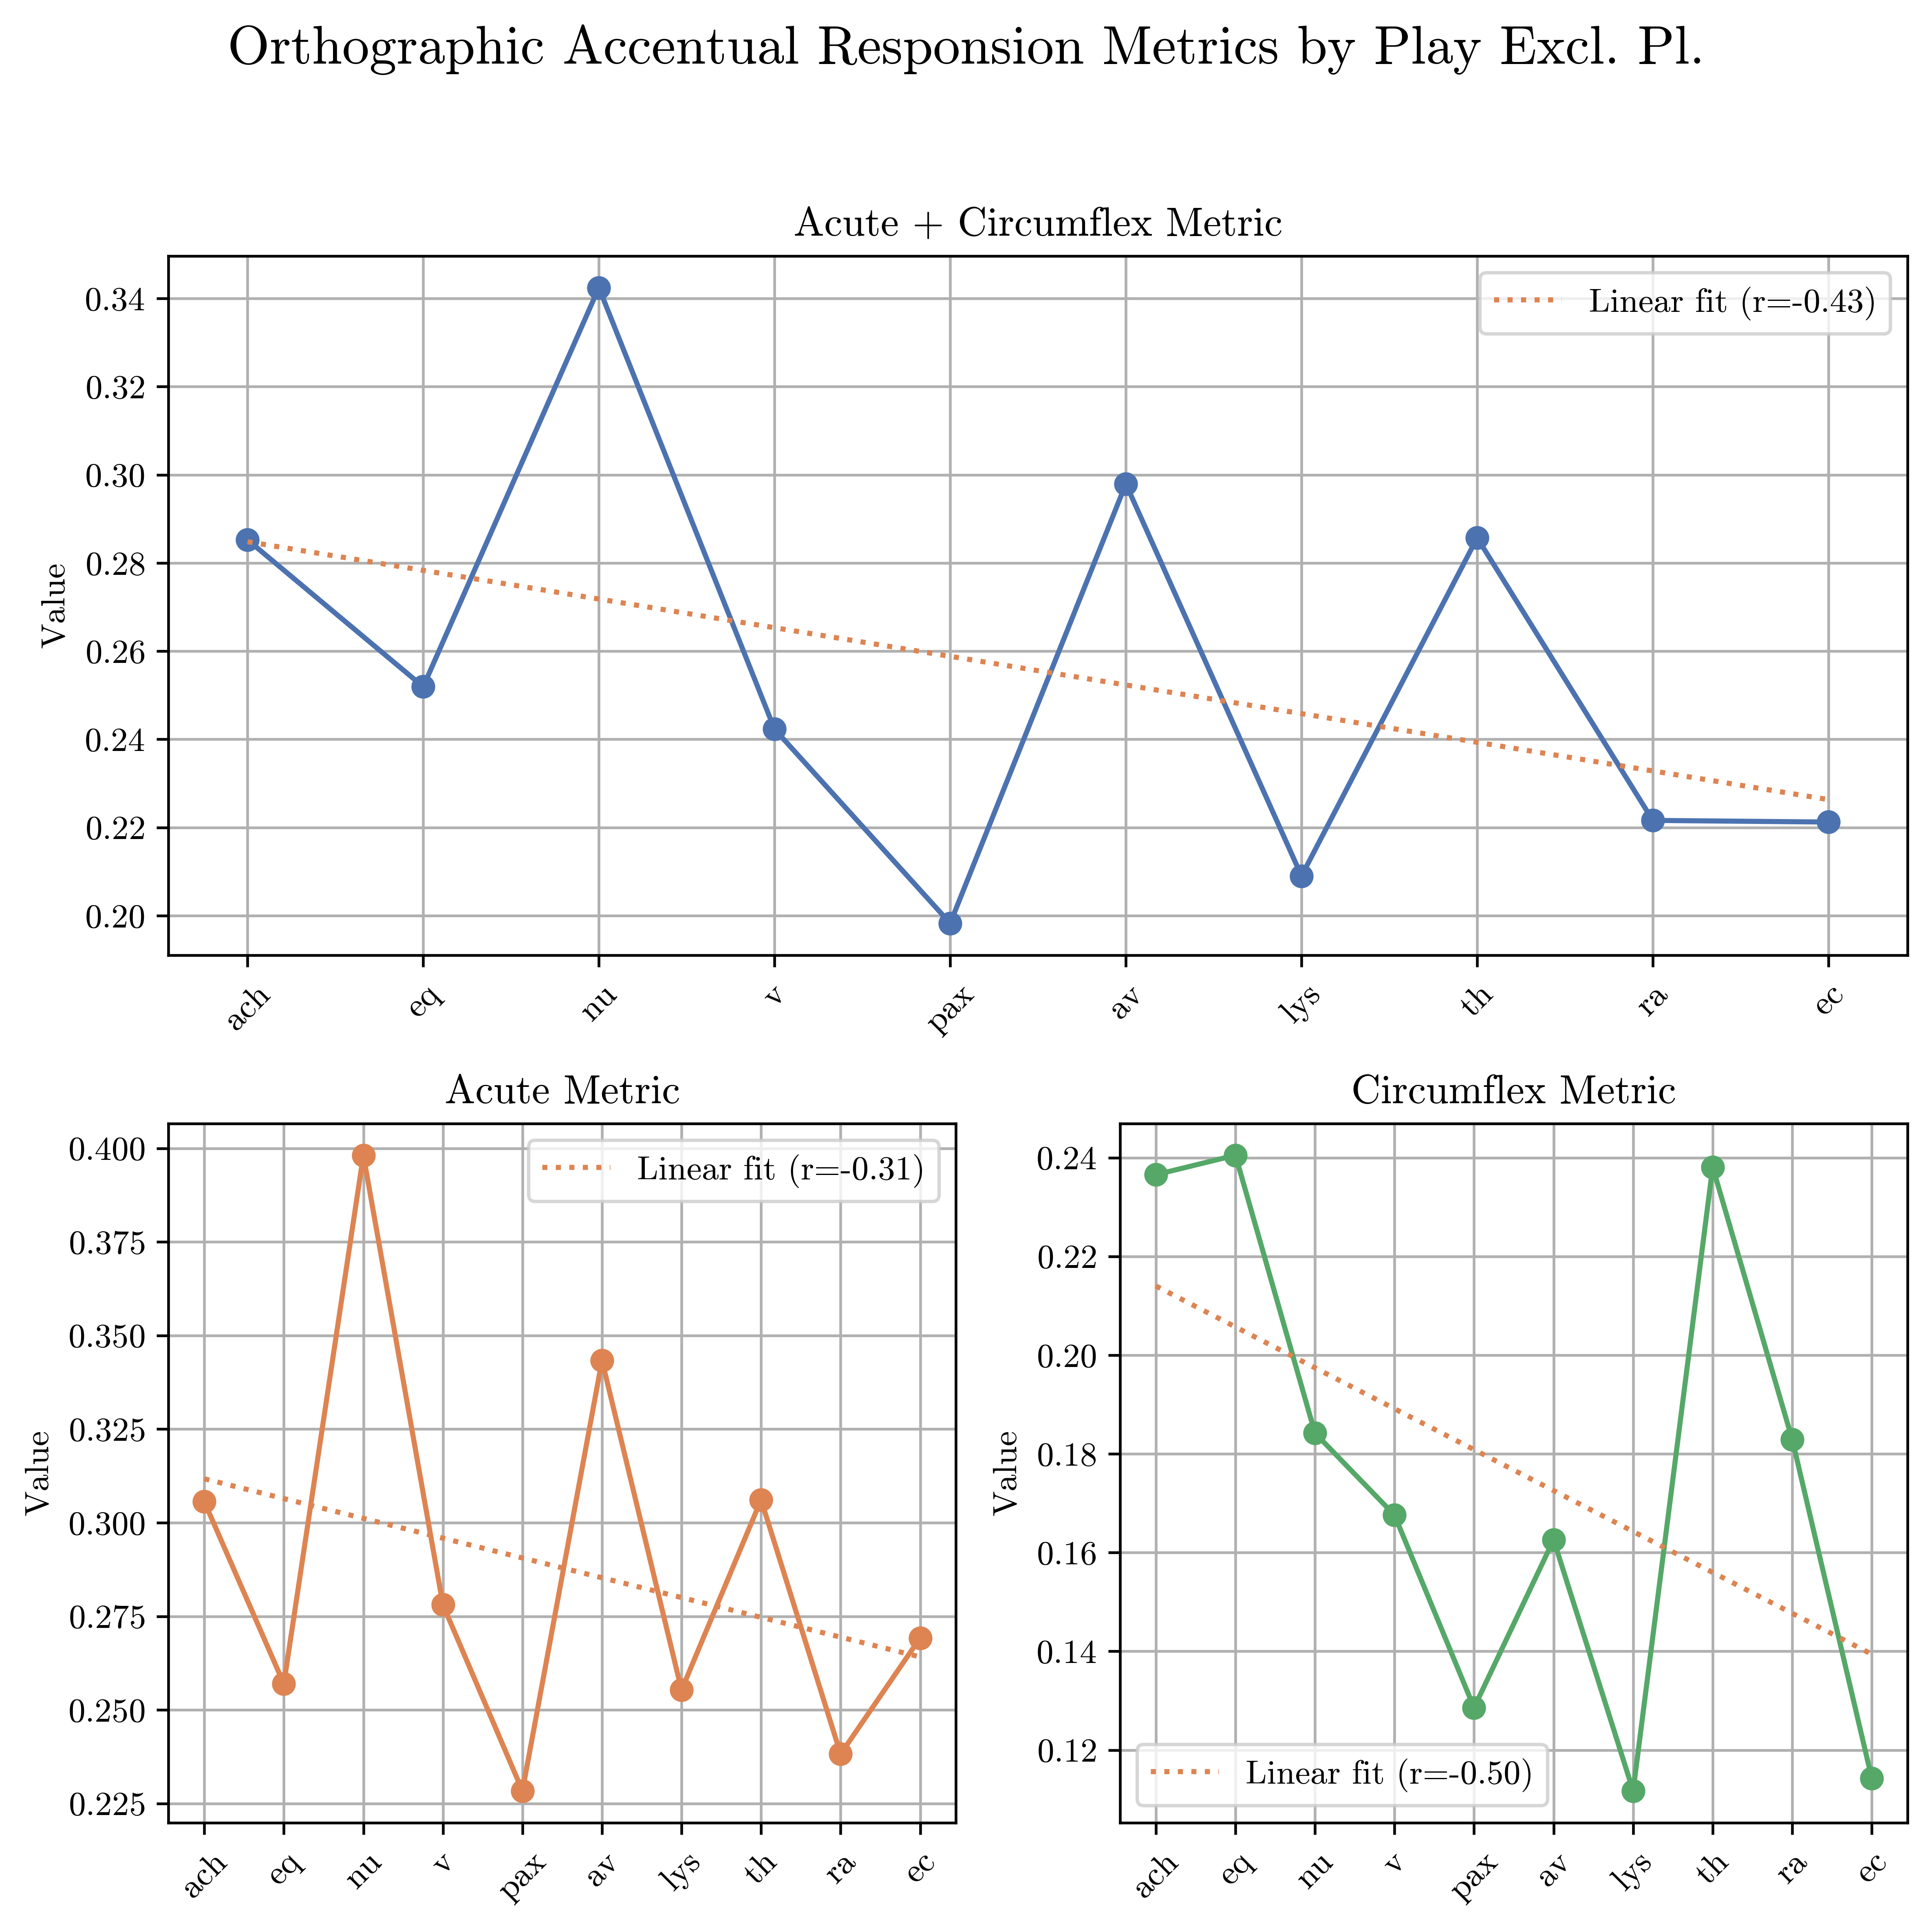

In [3]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import linregress
from matplotlib.gridspec import GridSpec

from aristophanis_cantica.plot import apply_plotting_poetry_palette
from aristophanis_cantica.stats import accentual_responsion_metric_play
from aristophanis_cantica.utils.utils import abbreviations

apply_plotting_poetry_palette()

abbreviations_no_pl = [abbrev for abbrev in abbreviations if abbrev != 'pl']

# ------------------------------------
# Plotting with 'pl' play
# ------------------------------------

play_stat_dictionary = {}
for play in abbreviations:
    xml_file = ROOT / f'data/compiled/responsion_{play}_compiled.xml'
    play_stat = accentual_responsion_metric_play(xml_file)
    play_stat_dictionary[play] = play_stat

data = play_stat_dictionary

x_labels = list(data.keys())
x_numeric = np.arange(len(x_labels))

# ------------------------------------

fig = plt.figure(figsize=(8, 8))
gs = GridSpec(2, 2, height_ratios=[1, 1])

ax0 = fig.add_subplot(gs[0, :])
ax1 = fig.add_subplot(gs[1, 0])
ax2 = fig.add_subplot(gs[1, 1])

metrics = ['acute_circumflex', 'acute', 'circumflex']
titles = ['Acute + Circumflex', 'Acute', 'Circumflex']

default_colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
axes = [ax0, ax1, ax2]

for i, metric in enumerate(metrics):
    y_values = [data[key][metric] for key in x_labels]

    slope, intercept, r_value, _, _ = linregress(x_numeric, y_values)
    linear_fit = slope * x_numeric + intercept

    ax = axes[i]
    series_color = default_colors[i % len(default_colors)]
    fit_color = default_colors[1]
    ax.plot(x_numeric, y_values, marker='o', color=series_color)
    ax.plot(x_numeric, linear_fit, linestyle=':', color=fit_color,
            label=f'Linear fit (r={r_value:.2f})')

    ax.set_title(f'{titles[i]} Metric')
    ax.set_xticks(x_numeric)
    ax.set_xticklabels(x_labels, rotation=45)
    ax.set_ylabel('Value')
    ax.grid(True)
    ax.legend()

plt.suptitle('Orthographic Accentual Responsion Metrics by Play', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig(ROOT / 'media/accentual_responsion_metrics_by_play.png', bbox_inches='tight', pad_inches=0.2)
plt.show()

# ------------------------------------
# Plotting without 'pl' play
# ------------------------------------

play_stat_dictionary = {}
for play in abbreviations_no_pl:
    xml_file = ROOT / f'data/compiled/responsion_{play}_compiled.xml'
    play_stat = accentual_responsion_metric_play(xml_file)
    play_stat_dictionary[play] = play_stat

data = play_stat_dictionary

x_labels = list(data.keys())
x_numeric = np.arange(len(x_labels))

# ------------------------------------

fig = plt.figure(figsize=(8, 8))
gs = GridSpec(2, 2, height_ratios=[1, 1])

ax0 = fig.add_subplot(gs[0, :])
ax1 = fig.add_subplot(gs[1, 0])
ax2 = fig.add_subplot(gs[1, 1])

axes = [ax0, ax1, ax2]

for i, metric in enumerate(metrics):
    y_values = [data[key][metric] for key in x_labels]

    slope, intercept, r_value, _, _ = linregress(x_numeric, y_values)
    linear_fit = slope * x_numeric + intercept

    ax = axes[i]
    series_color = default_colors[i % len(default_colors)]
    fit_color = default_colors[1]
    ax.plot(x_numeric, y_values, marker='o', color=series_color)
    ax.plot(x_numeric, linear_fit, linestyle=':', color=fit_color,
            label=f'Linear fit (r={r_value:.2f})')

    ax.set_title(f'{titles[i]} Metric')
    ax.set_xticks(x_numeric)
    ax.set_xticklabels(x_labels, rotation=45)
    ax.set_ylabel('Value')
    ax.grid(True)
    ax.legend()

plt.suptitle('Orthographic Accentual Responsion Metrics by Play Excl. Pl.', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig(ROOT / 'media/accentual_responsion_metrics_by_play_excl_pl.png', bbox_inches='tight', pad_inches=0.2)
plt.show()


In [4]:
import matplotlib.pyplot as plt
from scipy.stats import linregress
from lxml import etree
from tabulate import tabulate
from aristophanis_cantica.plot import apply_plotting_poetry_palette
from aristophanis_cantica.stats import accentually_responding_syllables_of_strophes_polystrophic, count_all_accents_canticum
from aristophanis_cantica.utils.utils import abbreviations, get_canticum_ids
from scipy.stats import pearsonr

apply_plotting_poetry_palette()

def color_ratio(value):
    formatted = f"{value:.2f}"
    return f"[92m{formatted}[0m" if value > 0 else f"[91m{formatted}[0m"

canticum_ids = get_canticum_ids(abbreviations)
print(f"Number of cantica: {len(canticum_ids)}")
table_data = []

acute_ratios = []
grave_ratios = []
circumflex_ratios = []
pitch_ratios = []
labels = []

for idx, canticum in enumerate(canticum_ids):
    infix = canticum[:-2]
    xml_file = ROOT / f"data/compiled/responsion_{infix}_compiled.xml"
    tree = etree.parse(xml_file)

    strophes = tree.xpath(f'//*[self::strophe or self::antistrophe][@responsion="{canticum}"]')
    accent_maps = accentually_responding_syllables_of_strophes_polystrophic(*strophes)

    total_accent_sums = count_all_accents_canticum(tree, canticum)
    accent_responsion_counts = {
        'acute': sum(len(d) for d in accent_maps[0]),
        'grave': sum(len(d) for d in accent_maps[1]),
        'circumflex': sum(len(d) for d in accent_maps[2])
    }

    acute_total = total_accent_sums['acute']
    grave_total = total_accent_sums['grave']
    circumflex_total = total_accent_sums['circumflex']

    acute_stat = accent_responsion_counts['acute'] / acute_total if acute_total > 0 else 0
    grave_stat = accent_responsion_counts['grave'] / grave_total if grave_total > 0 else 0
    circumflex_stat = accent_responsion_counts['circumflex'] / circumflex_total if circumflex_total > 0 else 0

    pitch_numerator = accent_responsion_counts['acute'] + accent_responsion_counts['circumflex']
    pitch_denominator = acute_total + circumflex_total
    pitch_stat = pitch_numerator / pitch_denominator if pitch_denominator > 0 else 0

    table_data.append([
        canticum,
        f"{accent_responsion_counts['acute']} / {acute_total} = {color_ratio(acute_stat)}",
        f"{accent_responsion_counts['grave']} / {grave_total} = {color_ratio(grave_stat)}",
        f"{accent_responsion_counts['circumflex']} / {circumflex_total} = {color_ratio(circumflex_stat)}",
        f"{pitch_numerator} / {pitch_denominator} = {color_ratio(pitch_stat)}"
    ])

    labels.append(canticum)
    acute_ratios.append(acute_stat)
    grave_ratios.append(grave_stat)
    circumflex_ratios.append(circumflex_stat)
    pitch_ratios.append(pitch_stat)

# Print the table
print(tabulate(
    table_data,
    headers=["Canticum", "Acute", "Grave", "Circumflex", "Acute + Circumflex"],
    tablefmt="github"
))



Number of cantica: 78

accentually_responding_syllables_of_lines_polystrophic:
	All double types at ordinal 3 in lines ['211-212', '226'].

accentually_responding_syllables_of_lines_polystrophic:
	All double types at ordinal 6 in lines ['211-212', '226'].

accentually_responding_syllables_of_lines_polystrophic:
	All double types at ordinal 9 in lines ['211-212', '226'].

accentually_responding_syllables_of_lines_polystrophic: 
	Mixed types at ordinal 18 in lines ['215-217', '230-233'].

accentually_responding_syllables_of_lines_polystrophic:
	All double types at ordinal 21 in lines ['215-217', '230-233'].

accentually_responding_syllables_of_lines_polystrophic:
	All double types at ordinal 24 in lines ['215-217', '230-233'].

accentually_responding_syllables_of_lines_polystrophic:
	All double types at ordinal 27 in lines ['215-217', '230-233'].

accentually_responding_syllables_of_lines_polystrophic:
	All double types at ordinal 30 in lines ['215-217', '230-233'].

accentually_respondi